# EDA — Text Classification

## Import libraries

In [1]:
## Add absolute path to this notebook
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import string
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

from src.configs.config import DEFAULT_CATEGORIES, STOPWORD_RATIOS
from src.data.preprocess import load_20newsgroups_raw, clean_text
from src.data.eda import show_long_short_docs, plot_top_ngrams
from src.features.build_features import stopwords_for_ratio, build_vectorizer

In [3]:
pd.set_option('display.max_colwidth', None)

## EDA (Overall)

### Load Data

In [4]:
train_df, test_df = load_20newsgroups_raw(categories=DEFAULT_CATEGORIES)

print(f"Train shape: {len(train_df)}")

Train shape: 2242


### 1. Data Types & Info

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2242 entries, 0 to 2241
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         2242 non-null   str  
 1   target       2242 non-null   int64
 2   target_name  2242 non-null   str  
dtypes: int64(1), str(2)
memory usage: 52.7 KB


There is no null entry

In [6]:
train_df.describe()

,target
count,2242.000000
mean,1.418822
std,1.086144
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,3.000000


In [7]:
train_df.head()

text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

The text is highly noisy and unstructured. It contains raw escape characters, tabular data, and boilerplate forum artifacts that make it unsuitable for direct analysis.

Recommended Cleaning Steps
- Email Removal: Strips out all email addresses.
- Signature Removal: Deletes signature lines (lines starting with --).
- Lowercasing: Converts all text to lowercase.

### 2. Target Distribution

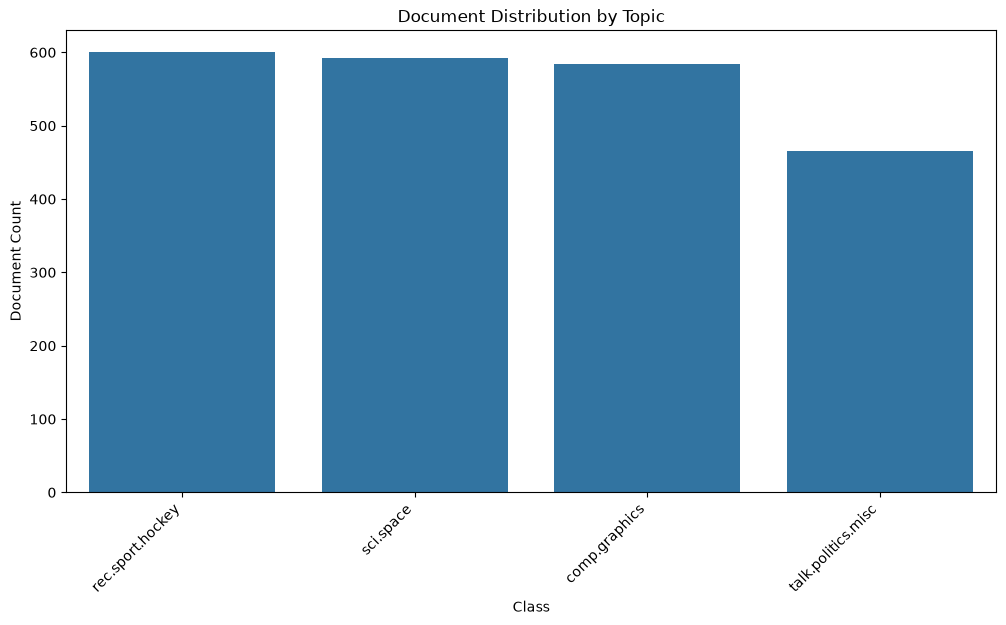

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=train_df, x='target_name', order=train_df['target_name'].value_counts().index)
plt.title('Document Distribution by Topic')
plt.xlabel('Class')
plt.ylabel('Document Count')
plt.xticks(rotation=45, ha='right') 
plt.show()

The class distribution is relatively balanced across 4 categories. This is an ideal scenario for text classification, meaning we will not need to apply complex resampling techniques.

### 2. Check Missing Values & Duplicates

In [9]:
missing_count = train_df['text'].isna().sum()
empty_count = train_df['text'].dropna().str.strip().eq('').sum()
duplicate_count = train_df.duplicated(subset=['text']).sum()

print(f"Missing text count: {missing_count}")
print(f"Empty text count: {empty_count}")
print(f"Duplicate count: {duplicate_count}")

Missing text count: 0
Empty text count: 56
Duplicate count: 50


The duplicate entries consist mainly of empty strings, they should be removed before training.

In [10]:
show_long_short_docs(train_df, 'text')

--- Short document examples ---


,text,target_name
15,,comp.graphics
33,\n\n,talk.politics.misc
71,,comp.graphics



--- Long document examples ---


text  \
10  Archive-name: hockey-faq\n\nrec.sport.hockey answers to Frequently Asked Questions and other news:\n \nContents:\n\n0. New Info.\n1. NHL\n2. NHL Minor Leagues\n3. College Hockey (North America)\n4. Other leagues (e.g. Europe, Canada Cup tournament)\n5. E-mail files\n6. USENET Hockey Pool\n7. Up-coming Dates\n8. Answers to some frequently asked questions\n9. Miscellaneous\n \n Send comments, suggestions and criticisms regarding this FAQ list via e-\nmail to hamlet@u.washington.edu.\n \n--------------------------------------------------------------------------\n \n 0. New Info.\n \n This section will describe additions since the last post so that you can \ndecide if there is anything worth reading. Paragraphs containing new \ninformation will be preceded by two asterisks (**).\n\n 1.: New Anaheim contact, Winnipeg to keep affiliate in Moncton.\n 2.: New Milwaukee contact, IHL broadcaster of the year named, Rheaume to \nstart against Cyclones, San Diego sets record.\n 3.: Ticket info included for 1994 NCAA Division I Championships.\n 4.: World Championship Pool B results listed, Sweden Hockey Games final \nstandings listed, Swedish Elite League final standings listed, new Olypmic \nHockey mailing list.\n 5.: New Montreal mailing list address.\n 6.: \n 7.: \n 8.: \n 9.: \n\n--------------------------------------------------------------------------\n \n  1. NHL - National Hockey League\n \n For detailed information concerning a team (particularly where to get \ntickets and merchandise, where to watch games in town....), send e-mail to \nthe net contact(s) for the team.\n\n                             First   # of   Last\n Team                   Div  Season  Cups   Cup    Net Contacts\n ---------------------  ---  ------  ----  ------ ----------------------\n**\n Anaheim Mighty Ducks    -   93-94      -    -    Kris Myers\n                                                  kris@fs2.assist.uci.edu\n Boston Bruins           A   24-25      5  71-72  \n Buffalo Sabres          A   70-71      0    -    Jeff Horvath\n                                                  jhorvath@macc.wisc.edu\n Calgary Flames          S   80-81*     1  88-89  CALDWELL8102@mtroyal.ab.ca\n Chicago Blackhawks      N   26-27      3  60-61  John Scholvin\n                                                  scholvin@casbah.acns.nwu.edu\n Detroit Red Wings       N   33-34*     7  54-55  SGLENN@cmsa.gmr.com\n Edmonton Oilers         S   79-80*     5  89-90  Andrew Scott\n                                                  andrew@idacom.hp.com\n Hartford Whalers        A   79-80*     0    -    Matthew Olsen\n                                                  dmolsen@athena.mit.edu\n Los Angeles Kings       S   67-68      0    -    Stan Willis\n                                                  willis@empire.dnet.hac.com\n Minnesota North Stars   N   67-68*     0    -    Mitch McGowan\n                                                  hamlet@u.washington.edu\n Montreal Canadiens      A   17-18     22  85-86  \n New Jersey Devils       P   82-83*     0    -    \n New York Islanders      P   72-73      4  82-83  Mark Anania\n                                                  ananim@rpi.edu\n New York Rangers        P   26-27      3  39-40  Paul Romano\n                                                  romano@monolith.bellcore.com\n Ottawa Senators         A   92-93      0    -    Scott Simpson\n                                                  simpson@bnr.ca\n Philadelphia Flyers     P   67-68      2  74-75  Pete Clark\n                                                  seth@hos1cad.att.com\n Pittsburgh Penguins     P   67-68      2  91-92  Lori Iannamico\n                                                  lli+@cs.cmu.edu\n                                                  Thomas Sullivan\n                                                  tms@cs.cmu.edu\n Quebec Nordiques        A   79-80*     0    -\n St. Louis Blues         N   67-68      0    -    Joseph Achkar\n    

### 3. Punctation & Number Analysis

In [11]:
train_df['char_count'] = train_df['text'].apply(len)
train_df['punct_count'] = train_df['text'].apply(lambda x: len([c for c in x if c in string.punctuation]))

train_df['digit_count'] = train_df['text'].apply(lambda x: len(re.findall(r'\d', x)))

train_df['punct_ratio'] = train_df['punct_count'] / (train_df['char_count'] + 1)
train_df['digit_ratio'] = train_df['digit_count'] / (train_df['char_count'] + 1)

print("Top 5 texts with the highest PUNCTUATION RATIO:")
display(train_df.sort_values(by='punct_ratio', ascending=False)[['target_name', 'punct_ratio', 'text']].head(5))

print("Top 5 texts with the highest DIGIT RATIO:")
display(train_df.sort_values(by='digit_ratio', ascending=False)[['target_name', 'digit_ratio', 'text']].head(5))

Top 5 texts with the highest PUNCTUATION RATIO:


,target_name,punct_ratio,text
1518,comp.graphics,0.975000,==============================================================================\n
2148,comp.graphics,0.972973,------------------------------------
1265,talk.politics.misc,0.897727,\n ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n ^^^
1229,rec.sport.hockey,0.750000,;^)
1209,talk.politics.misc,0.645669,============================================================================\nDavid Matthew Deane (deane@binah.cc.brandeis.edu)


Top 5 texts with the highest DIGIT RATIO:


target_name  digit_ratio  \
1472  rec.sport.hockey     0.406491   
1059         sci.space     0.300139   
1616  rec.sport.hockey     0.287810   
1243  rec.sport.hockey     0.274942   
196   rec.sport.hockey     0.270759   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

Texts exhibiting unusually high ratios of punctuation marks or digits generally represent tabular data, code blocks, or residual PGP signatures rather than natural human language.

Recommended Cleaning Steps
- Alphabetical Filtering: Removes numbers, punctuation, and special characters (keeps only a-z and spaces).
- Whitespace Normalization: Collapses multiple spaces into a single space and trims leading/trailing whitespace.
- Null Dropping: Removes any rows that became completely empty after cleaning and resets the dataframe index.

## Clean Text

In [12]:
train_df = clean_text(train_df)

In [13]:
train_df[["clean_text", "target_name"]].head(5)

,clean_text,target_name
0,pascal perret in article wrote funny thing the internet i have no idea what xv might be except that it might be something to do with x windows on pcs if you know and have used it and think that it is good email me dv x is a common abbreviation for quarterdeck corporation s desqview x software i have not used dv x yet but reading the blurbs that quarterdeck sent me it sounds pretty great allows multiple dos machines the way that os does but without requiring mb of ram to get os going pre emptive multi tasking network computing a proper x windows client server application this means that dos program can be used on other x windows computers on your network and that x windows programs can be used on your dv x computer although it is not a version of unix it effectively has many of unix s features and mostly you will be able to compile unix type programs using the djgpp or gnu c compilers they advertise regularly in all of the major computing and programming magazines they also have internet support online hope that this helps anyone wanting to know,comp.graphics
1,this notice will be posted weekly in sci space sci astro and sci space shuttle the frequently asked questions faq list for sci space and sci astro is posted approximately monthly it also covers many questions that come up on sci space shuttle for shuttle launch dates see below the faq is posted with a long expiration date so a copy may be in your news spool directory look at old articles in sci space if not here are two ways to get a copy without waiting for the next posting if your machine is on the internet it can be obtained by anonymous ftp from the space archive at ames arc nasa gov in directory pub space faq otherwise send email to containing the single line help the archive server will return directions on how to use it to get an index of files in the faq directory send email containing the lines send space faq index send space faq faq use these files as a guide to which other files to retrieve to answer your questions shuttle launch dates are posted by ken hollis periodically in sci space shuttle a copy of his manifest is now available in the ames archive in pub space faq manifest and may be requested from the email archive server with send space faq manifest please get this document instead of posting requests for information on launches and landings,sci.space
2,nhl results for games played standings patrick adams norris smythe tm w l t pt tm w l t pt tm w l t pt tm w l t pt xpit xbos xchi xvan ywas yque ydet ycal ynj ymon ytor yla ynyi ybuf ystl ywin phl har min edm nyr ott tb sj x clinched division title y clinched playoff berth minnesota north stars detroit red wings st period min mcphee ludwig nd period min dahlen courtnall gagner pp det drake howe ogrodnick det ysebaert lidstrom howe pp rd period det ciccarelli coffey chiasson pp det kennedy burr probert det yzerman ciccarelli gallant min dahlen courtnall gagner powerplay opportunities north stars of red wings of shots on goal north stars red wings minnesota north stars casey shots saves detroit red wings cheveldae shots saves att philadelphia flyers buffalo sabres st period phl recchi galley lindros nd period phl hawgood dineen eklund pp phl dineen mcgill sh buf barnaby hawerchuk smehlik pp buf wood lafontaine ledyard pp buf mogilny hawerchuk carney pp rd period phl eklund dineen beranek buf mogilny errey lafontaine phl dineen brind amour pp phl dineen brind amour galley sh phl acton dineen brind amour powerplay opportunities flyers of sabres of shots on goal flyers sabres philadelphia flyers soderstrom shots saves buffalo sabres fuhr shots saves hasek second shots saves att edmonton oilers winnipeg jets st period win shannon steen davydov pp nd period win selanne olausson win zhamnov selanne rd period none powerplay opportunities oilers of jets of shots on goal oilers jets edmonton oilers ranford shots saves winnipeg jets essensa shots saves att toronto maple leafs chicago blackh

## EDA (In-depth)

### 1. Text Length Analysis

In [14]:
# Count number of words
train_df['clean_word_count'] = train_df['clean_text'].apply(lambda x: len(str(x).split()))
empty_docs = len(train_df[train_df['clean_word_count'] == 0])
print(f"Number of empty texts: {empty_docs}")

Number of empty texts: 0


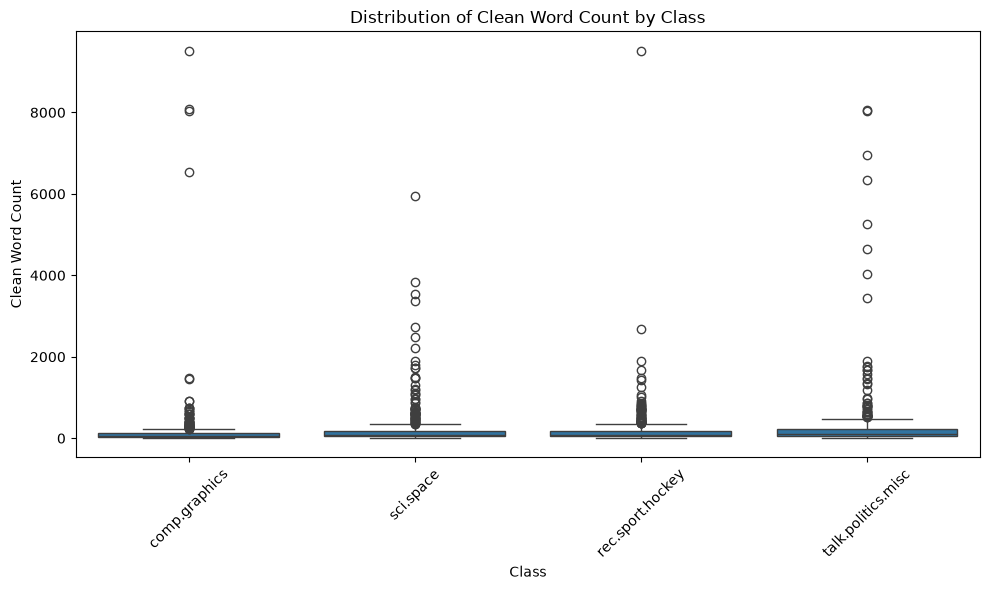

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='target_name', y='clean_word_count')
plt.title('Distribution of Clean Word Count by Class')
plt.xlabel('Class')
plt.ylabel('Clean Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Heavily Skewed Distributions: The dense clusters of boxes near the x-axis indicate that the vast majority of documents across all categories are relatively short.
- Presence of Extreme Outliers: Every class exhibits a long "tail" of outliers extending far up the y-axis. This denotes a significant right skew.
- Exceptional Lengths: While typical posts are brief, there are exceptionally long documents in the dataset, with some outliers in comp.graphics and rec.sport.hockey reaching between 8,000 and 10,000 words.

In [16]:
show_long_short_docs(train_df, 'clean_text')

--- Short document examples ---


,clean_text,target_name
202,just testing no flames please,rec.sport.hockey
789,go heavy or go home,comp.graphics
891,please get a real life,sci.space



--- Long document examples ---


clean_text  \
2110  archive name jpeg faq last modified april this faq article discusses jpeg image compression suggestions for additions and clarifications are welcome new since version of april new versions of image archiver and pmjpeg for os this article includes the following sections what is jpeg why use jpeg when should i use jpeg and when should i stick with gif how well does jpeg compress images what are good quality settings for jpeg where can i get jpeg software a canned software viewers etc b source code what s all this hoopla about color quantization how does jpeg work what about lossless jpeg why all the argument about file formats how do i recognize which file format i have and what do i do about it what about arithmetic coding does loss accumulate with repeated compression decompression what are some rules of thumb for converting gif images to jpeg sections are basic info that every jpeg user needs to know sections are advanced info for the curious this article is posted every weeks you can always find the latest version in the news answers archive at rtfm mit edu by ftp fetch pub usenet news answers jpeg faq or if you don t have ftp send e mail to with body send usenet news answers jpeg faq many other faq articles are also stored in this archive for more instructions on use of the archive send e mail to the same address with the words help and index no quotes on separate lines if you don t get a reply the server may be misreading your return address add a line such as path to specify your correct e mail address to reply to what is jpeg jpeg pronounced jay peg is a standardized image compression mechanism jpeg stands for joint photographic experts group the original name of the committee that wrote the standard jpeg is designed for compressing either full color or gray scale digital images of natural real world scenes it does not work so well on non realistic images such as cartoons or line drawings jpeg does not handle black and white bit per pixel images nor does it handle motion picture compression standards for compressing those types of images are being worked on by other committees named jbig and mpeg respectively jpeg is lossy meaning that the image you get out of decompression isn t quite identical to what you originally put in the algorithm achieves much of its compression by exploiting known limitations of the human eye notably the fact that small color details aren t perceived as well as small details of light and dark thus jpeg is intended for compressing images that will be looked at by humans if you plan to machine analyze your images the small errors introduced by jpeg may be a problem for you even if they are invisible to the eye a useful property of jpeg is that the degree of lossiness can be varied by adjusting compression parameters this means that the image maker can trade off file size against output image quality you can make extremely small files if you don t mind poor quality this is useful for indexing image archives making thumbnail views or icons etc etc conversely if you aren t happy with the output quality at the default compression setting you can jack up the quality until you are satisfied and accept lesser compression why use jpeg there are two good reasons to make your image files smaller and to store bit per pixel color data instead of bit per pixel data making image files smaller is a big win for transmitting files across networks and for archiving libraries of images being able to compress a mbyte full color file down to kbytes or so makes a big difference in disk space and transmission time if you are comparing gif and jpeg the size ratio is more like four to one more details below if your viewing software doesn t support jpeg directly you ll have to convert jpeg to some other format for viewing or manipulating images even with a jpeg capable viewer it takes longer to decode and view a jpeg image than to view an image of a simpler format gif for instance thus using jpeg is es

- Removing Short Texts: Documents with fewer than 5 words will be removed, as they lack sufficient context for meaningful analysis.

- Retaining Long Texts: Extremely long documents will be retained, because they still contain valid and valuable semantic information.

### 2. Samples In Each Class

In [17]:
for target in train_df['target_name'].unique():
    print(f"--- Class: {target} ---")
    display(train_df[train_df['target_name'] == target][['clean_text', 'target_name']].head(2))

--- Class: comp.graphics ---


,clean_text,target_name
0,pascal perret in article wrote funny thing the internet i have no idea what xv might be except that it might be something to do with x windows on pcs if you know and have used it and think that it is good email me dv x is a common abbreviation for quarterdeck corporation s desqview x software i have not used dv x yet but reading the blurbs that quarterdeck sent me it sounds pretty great allows multiple dos machines the way that os does but without requiring mb of ram to get os going pre emptive multi tasking network computing a proper x windows client server application this means that dos program can be used on other x windows computers on your network and that x windows programs can be used on your dv x computer although it is not a version of unix it effectively has many of unix s features and mostly you will be able to compile unix type programs using the djgpp or gnu c compilers they advertise regularly in all of the major computing and programming magazines they also have internet support online hope that this helps anyone wanting to know,comp.graphics
7,re majority of users not readding from floppy well how about those of us who have picture cd roms and would like to use cview because it is fast and it works well but can t because the moron lacked the foresight to create the temp file in the program s path not the current didrectory actually the most flexible way to create temp files is to check for a temp or tmp environment variable and create the files on the drive and directory pointedto by the variable this is pretty much a standard for dos windows and os applications unfortunately cview does not pay attention to the temp environment variable,comp.graphics


--- Class: sci.space ---


,clean_text,target_name
1,this notice will be posted weekly in sci space sci astro and sci space shuttle the frequently asked questions faq list for sci space and sci astro is posted approximately monthly it also covers many questions that come up on sci space shuttle for shuttle launch dates see below the faq is posted with a long expiration date so a copy may be in your news spool directory look at old articles in sci space if not here are two ways to get a copy without waiting for the next posting if your machine is on the internet it can be obtained by anonymous ftp from the space archive at ames arc nasa gov in directory pub space faq otherwise send email to containing the single line help the archive server will return directions on how to use it to get an index of files in the faq directory send email containing the lines send space faq index send space faq faq use these files as a guide to which other files to retrieve to answer your questions shuttle launch dates are posted by ken hollis periodically in sci space shuttle a copy of his manifest is now available in the ames archive in pub space faq manifest and may be requested from the email archive server with send space faq manifest please get this document instead of posting requests for information on launches and landings,sci.space
3,for the purpose of a contest i d bet some things could be cut like fuel for re entry any kind of heat shielding etc etc even still if the contest participants had to fund dc development it probably wouldn t be worth it to develop dc just for the contest just give me the cheapest heaviest lift man rated or at least under or so gs booster if i don t have to pay for dc development great i ll use it but back to the contest goals there was a recent article in aw st about a low cost it s all relative manned return to the moon a general dynamics scheme involving a titan iv shuttle to lift a centaur upper stage lev and crew capsule the mission consists of delivering two unmanned payloads to the lunar surface followed by a manned mission total cost us was billion joint esa nasa project was billion for the us share i didn t find a mention of how long the crew could stay but i d bet that its around days and the total payload delivered was about metric tonnes so if you ignore the scientific payload hitch a ride in the crew habitation module no return trip and toss in a few more tonnes for the additional consumables to last another months then you might be able to get a year visit out of tonnes and in case its not obvious that s a wild ass guess a pretty boring visit since every trip outdoors eats up a bit of lox and i m not certain if a home brewed or college brewed life support system could last a year but let s round this up to tonnes convient since the gd plan talks about ton payloads delivered to the lunar surface this adds up to two centaurs two levs two shuttle flights all to put a single man on the moon for a year hmmm not really practical anyone got a cheaper better way of delivering tonnes to the lunar surface within the decade anyone have a more precise guess about how much a year s supply of consumables and equipment would weigh and i was wondering about the gd lev is it reusable or is it discarded to burn up on return to leo if its not discarded could it be refueled henry do you know anything about the gd lev i noted that it uses rl engines aren t they reusable restartable would a lev fit in a dc i ve forgotten if i ever knew what the cargo bay dimensions are for the dc all in all i m not certain that the single goal prize of staying on the moon for a year is wise and or useful how about a prize for the first non government sponsered unmanned moon landing then another for a manned moon landing then yet another for a system to extract consumables from lunar soil another for a reusable earth moon shuttle and so forth find some way to build civilian moonbase infrastructure having a single goal might result in a bunch of contestents givin

--- Class: rec.sport.hockey ---


,clean_text,target_name
2,nhl results for games played standings patrick adams norris smythe tm w l t pt tm w l t pt tm w l t pt tm w l t pt xpit xbos xchi xvan ywas yque ydet ycal ynj ymon ytor yla ynyi ybuf ystl ywin phl har min edm nyr ott tb sj x clinched division title y clinched playoff berth minnesota north stars detroit red wings st period min mcphee ludwig nd period min dahlen courtnall gagner pp det drake howe ogrodnick det ysebaert lidstrom howe pp rd period det ciccarelli coffey chiasson pp det kennedy burr probert det yzerman ciccarelli gallant min dahlen courtnall gagner powerplay opportunities north stars of red wings of shots on goal north stars red wings minnesota north stars casey shots saves detroit red wings cheveldae shots saves att philadelphia flyers buffalo sabres st period phl recchi galley lindros nd period phl hawgood dineen eklund pp phl dineen mcgill sh buf barnaby hawerchuk smehlik pp buf wood lafontaine ledyard pp buf mogilny hawerchuk carney pp rd period phl eklund dineen beranek buf mogilny errey lafontaine phl dineen brind amour pp phl dineen brind amour galley sh phl acton dineen brind amour powerplay opportunities flyers of sabres of shots on goal flyers sabres philadelphia flyers soderstrom shots saves buffalo sabres fuhr shots saves hasek second shots saves att edmonton oilers winnipeg jets st period win shannon steen davydov pp nd period win selanne olausson win zhamnov selanne rd period none powerplay opportunities oilers of jets of shots on goal oilers jets edmonton oilers ranford shots saves winnipeg jets essensa shots saves att toronto maple leafs chicago blackhawks st period tor baumgartner nd period chi roenick murphy chelios tor andreychuk mironov lefebvre chi murphy roenick chelios pp rd period chi matteau powerplay opportunities maple leafs of blackhawks of shots on goal maple leafs blackhawks toronto maple leafs potvin shots saves chicago blackhawks belfour shots saves att tampa bay lightning st louis blues st period stl shanahan brown felsner stl miller bassen brown stl bassen zombo nd period stl bassen hedican miller stl miller zombo hedican tbl maltais hamrlik tbl bergland harvey gilhen tbl shanahan emerson rd period tbl creighton bergland bergevin tbl chambers zamuner cole tbl cole beers bradley powerplay opportunities lightning of blues of shots on goal lightning blues tampa bay lightning jablonski shots saves bergeron third shots saves st louis blues joseph shots saves hebert third shots saves att san jose sharks calgary flames st period none nd period sjs garpenlov odgers gaudreau pp cal nieuwendyk macinnis suter pp cal ranheim otto suter cal yawney nieuwendyk roberts cal berube paslawski skrudland rd period sjs wood odgers kisio cal reichel cal roberts musil paslawski pp sjs kisio cal paslawski ashton stern powerplay opportunities sharks of flames of shots on goal sharks flames san jose sharks irbe shots saves calgary flames vernon shots saves att vancouver canucks los angeles kings st period lak robitaille gretzky sandstrom van babych craven nedved pp lak sandstrom gretzky robitaille nd period van linden ronning courtnall pp van ward hunter nedved lak gretzky sandstrom robitaille lak zhitnik kurri robitaille pp lak millen hardy pp rd period van ronning dirk van ronning courtnall linden pp van linden courtnall ronning lak donnelly millen granato pp van courtnall ronning ratushny van ronning linden diduck en powerplay opportunities canucks of kings of shots on goal canucks kings vanocuver canucks whitmore shots saves los angeles kings stauber shots saves hrudey third shots saves att,rec.sport.hockey
4,yes but as has been mentioned many times before the islanders play at the talent level of their opponent since hartford is pitiful the islanders played pitiful since pittsburgh is great the isles will most likely play great this is most likely due to inexperience and very poor shooting to greg yes i have noticed that the islanders couldn t hit the broad side of a barn with t

--- Class: talk.politics.misc ---


,clean_text,target_name
13,the official and legal term for rape is the crime of forcing a female to submit to sexual intercourse please supply me with some references i was not aware that all states had the word female in the rape statutes i am sure others are surprised as well i know thats how it works in practice nice n fair not but was unaware that it was in the statutes as applying to females only uniformly throughout the u s chris there may be some confusion here the uniform crime reports program run by the fbi defines rape as a female victim only crime even though some states have the laws de sexed i suspect that this causes male victims of rape to be left out of the ucr data,talk.politics.misc
14,the white house office of the press secretary for immediate release april text of a letter from the president to the speaker of the house of representatives and the president pro tempore of the senate april dear mr speaker dear mr president as part of my continuing effort to keep the congress fully informed i am providing this report consistent with section of the war powers resolution to advise you of actions that i have ordered in support of the united nations efforts in bosnia herzegovina beginning with u n security council resolution of september the united nations has been actively addressing the crisis in the former yugoslavia the security council acted in resolution to establish a ban on all unauthorized military flights over bosnia herzegovina there have however been blatant violations of the ban and villages in bosnia have been bombed in response to these violations the security council decided in resolution of march to extend the ban to all unauthorized flights over bosnia herzegovina and to authorize member states acting nationally or through regional organi zations to take all necessary measures to ensure compliance nato s north atlantic council nac agreed to provide nato air enforcement for the no fly zone the u n secretary general was notified of nato s decision to proceed with operation deny flight and an activation order was delivered to participating allies the united states actively supported these decisions at my direction the joint chiefs of staff sent an execute order to all u s forces participating in the nato force for the conduct of phased air operations to prevent flights not authorized by the united nations over bosnia herzegovina the u s forces initially assigned to this operation consist of f and f a fighter aircraft and supporting tanker aircraft these aircraft commenced enforcement operations at a m e d t on april the fighter aircraft are equipped for combat to accomplish their mission and for self defense nato has positioned forces and has established combat air patrol cap stations within the control of airborne early warning aew aircraft the u s cap aircraft will normally operate from bases in italy and from an aircraft carrier in the adriatic sea unauthorized aircraft entering or approaching the no fly zone will be identified interrogated intercepted escorted monitored and turned away in that order if these steps do not result in compliance with the no fly zone such aircraft may be engaged on the basis of proper authorization by nato military authorities and in accordance with the approved more over rules of engagement although we do not expect such action will be necessary the commander of unprofor the united nations protection force currently operating in bosnia herzegovina was consulted to ensure that his concerns for his force were fully considered before the rules of engagement were approved it is not possible to predict at this time how long such operations will be necessary i have directed u s armed forces to participate in these operations pursuant to my constitutional authority as commander in chief i am grateful for the con tinuing support that the congress has given to this effort and i look forward to continued cooperation as we move forward toward attainment of our goals in this reg

- What sci.space talks about: Space exploration infrastructure, NASA/Ames archives, FAQs for astronomy, space shuttle launch manifests, and logistics/costs for lunar missions (moonbases, payloads, and life support systems).

- Keywords for hockey (rec.sport.hockey): nhl, standings, playoff berth, period, powerplay (pp), shots on goal, saves, puck, teams (red wings, north stars, islanders, rangers), and players (gretzky, yzerman).

- Keywords for graphics (comp.graphics): x-windows, desqview/x, dos, unix, compilers (djgpp, gnu c), cd-rom, cview, and environment variables (temp/tmp).

- Keywords for politics (talk.politics.misc): white house, president (clinton), congress, statutes, war powers resolution, united nations (u n), bosnia herzegovina, nato, and military/f-16 aircraft.

- Classes prone to confusion: sci.space and talk.politics.misc can potentially be confused by NLP models. Both heavily feature official government/organizational correspondence, legalistic reporting terminology, and defense/aerospace-adjacent vocabulary (e.g., NASA, NATO, Titan IV rockets, and fighter aircraft).

### 3. Top Frequent Lexical Analysis

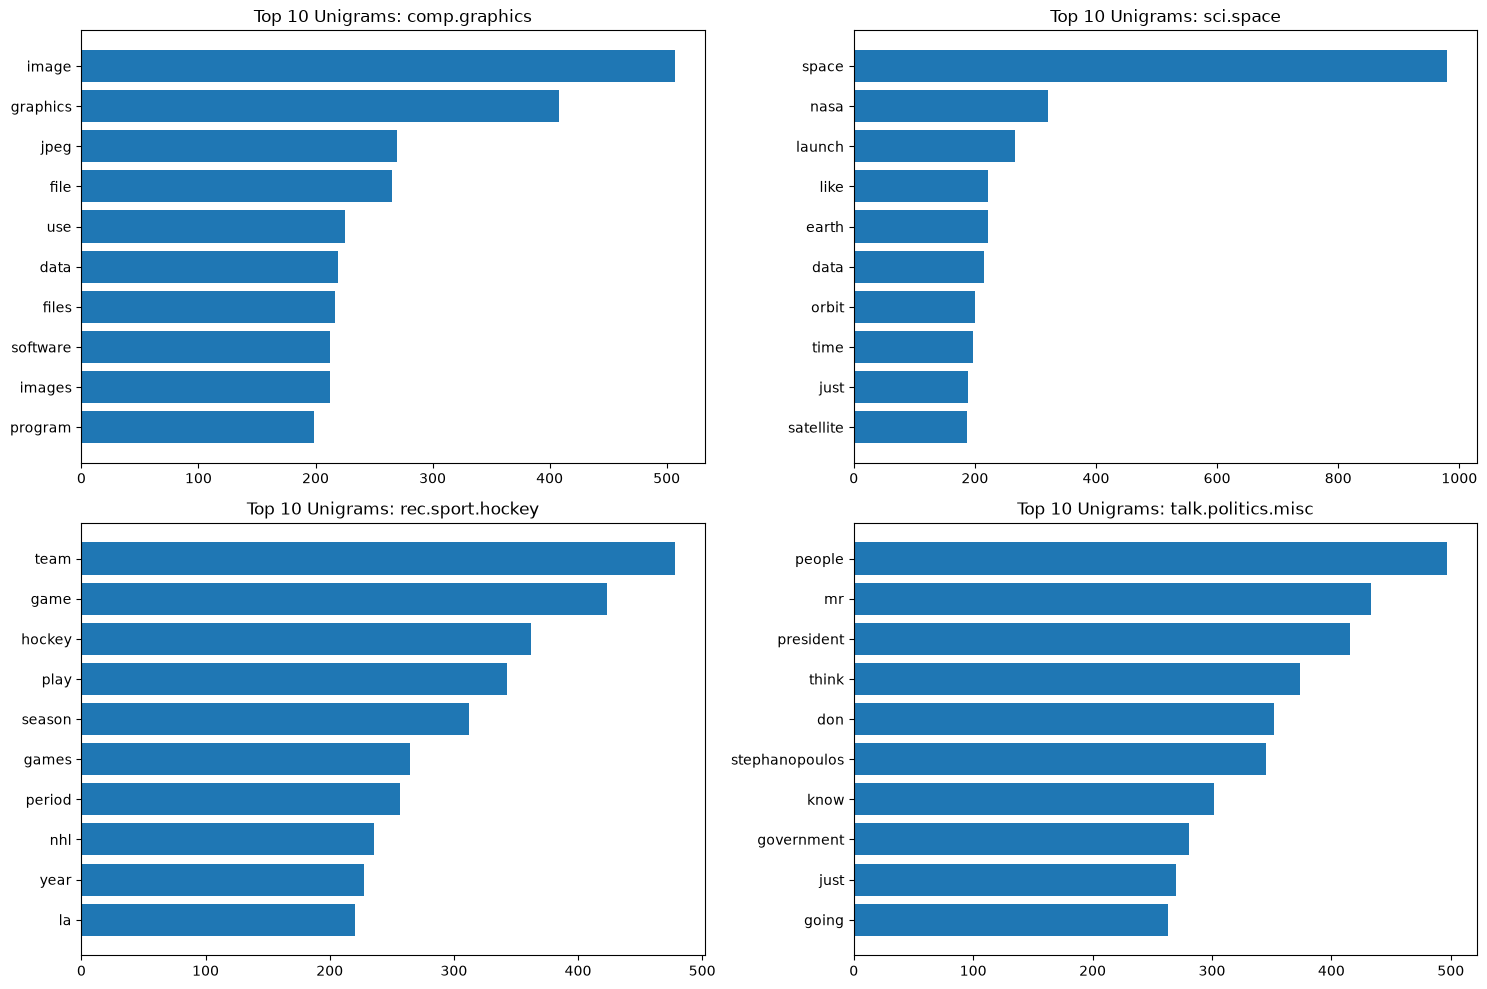

In [18]:
classes = train_df['target_name'].unique()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, target in enumerate(classes):
    corpus = train_df[train_df['target_name'] == target]['clean_text'].dropna().astype(str)
    plot_top_ngrams(corpus, f'Top 10 Unigrams: {target}', axes[i], n=10, ngram_range=(1, 1))

plt.tight_layout()
plt.show()

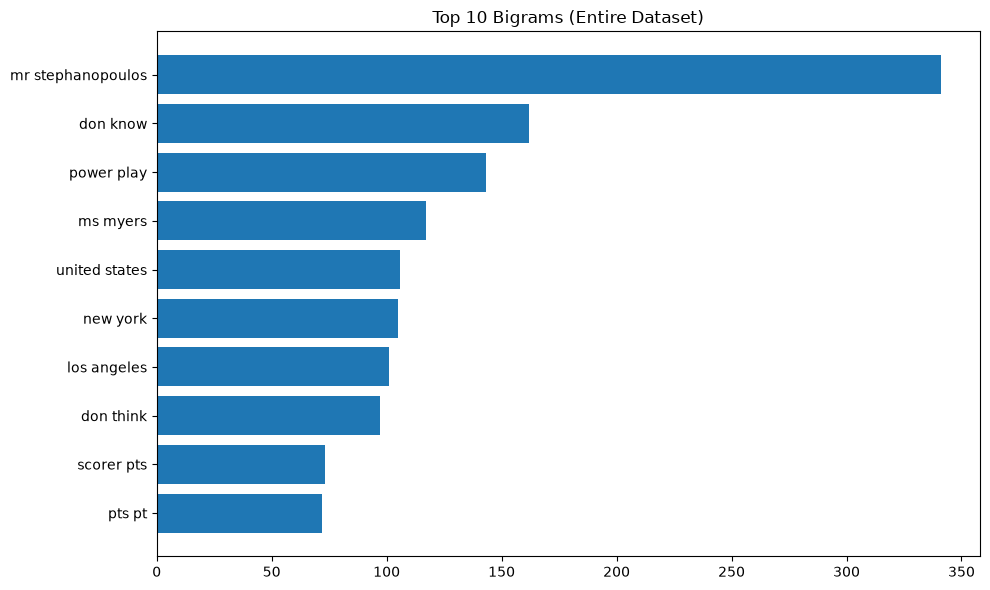

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
corpus_all = train_df['clean_text'].dropna().astype(str)
plot_top_ngrams(corpus_all, 'Top 10 Bigrams (Entire Dataset)', ax, n=10, ngram_range=(2, 2))
plt.tight_layout()
plt.show()

Comparing the lexical features of distinct classes (e.g., **sci.space** vs. **comp.graphics**) demonstrates excellent semantic separation. Each class is tightly clustered around its specific domain vocabulary. This strong distinctiveness suggests that once the noise is properly cleaned, even traditional algorithms like Naive Bayes or Logistic Regression (paired with TF-IDF) will achieve high accuracy.

### 4. Stopwords Analysis

In [20]:
sensitive_words = ['not', 'no', 'nor', 'never', 'very']

extracted_df = train_df.copy()
for w in sensitive_words:
    extracted_df[w] = extracted_df['clean_text'].astype(str).str.lower().str.count(rf'\b{w}\b')

stopword_table = extracted_df.groupby('target_name')[sensitive_words].sum()
display(stopword_table)

,not,no,nor,never,very
target_name,,,,,
comp.graphics,372,124,5,21,132
rec.sport.hockey,354,210,3,63,101
sci.space,475,182,8,44,144
talk.politics.misc,927,385,22,62,191


In [21]:
vocab_sizes = []

for ratio in STOPWORD_RATIOS:
    custom_stopwords = stopwords_for_ratio(ratio)
    vec = build_vectorizer(kind="count", stop_words=custom_stopwords)
    
    vec.fit(corpus)
    vocab_sizes.append({
        'stopword_ratio': ratio, 
        'stopwords_count': len(custom_stopwords) if custom_stopwords else 0,
        'vocab_size': len(vec.vocabulary_)
    })

vocab_df = pd.DataFrame(vocab_sizes)
display(vocab_df)

,stopword_ratio,stopwords_count,vocab_size
0,0.0,0,4998
1,0.2,64,4940
2,0.5,159,4861
3,0.8,254,4777
4,1.0,318,4721


In [22]:
sensitive_words = set(sensitive_words)
for ratio in STOPWORD_RATIOS:
    custom_stopwords = set(stopwords_for_ratio(ratio)) if ratio > 0 else set()
    removed_words = sensitive_words.intersection(custom_stopwords)
    print(f"Ratio {ratio}: Delete {list(removed_words)}")

Ratio 0.0: Delete []
Ratio 0.2: Delete []
Ratio 0.5: Delete []
Ratio 0.8: Delete ['never', 'no', 'not', 'nor']
Ratio 1.0: Delete ['never', 'nor', 'not', 'no', 'very']


## Summary

### EDA Summary & Key Insights

* **Target Distribution:** The dataset is well-balanced across its four target categories. No advanced resampling or class-weighting techniques are required prior to modeling.
* **Document Lengths:** Text lengths exhibit a severe right skew. While the vast majority of documents are short, extreme outliers extend up to 10,000 words. Documents with fewer than 5 words lack semantic value and should be dropped, while the long outliers should be retained as they contain valid contextual data.
* **Semantic Separability:** Lexical analysis reveals highly distinct, domain-specific vocabularies for the classes (e.g., NHL terms for hockey, OS terms for graphics).
* **Potential Class Confusion:** There is an anticipated overlap between `sci.space` and `talk.politics.misc` due to shared institutional, defense, and government-adjacent vocabulary (e.g., NASA, military, funding).
* **Stopword Sensitivity:** Aggressive stopword filtering (ratios of 0.8 and 1.0) actively strips out critical negation words like *not*, *no*, and *never*. It might be true that sensitive stopwords have minimal impact on the data because the classes are not polar opposites.

### Text Preprocessing

To clean the noisy raw text and prepare it for modeling, we apply the following preprocessing pipeline:
* **Remove Emails:** Strips out any email addresses present in the text.
* **Remove Signatures:** Deletes signature blocks (typically lines starting with `--`).
* **Lowercase Conversion:** Converts all characters to lowercase to maintain uniformity.
* **Alphabetical Filtering:** Removes all digits, punctuation, and special characters, retaining only English letters (`a-z`) and spaces.
* **Whitespace Normalization:** Collapses multiple spaces into a single space and trims leading/trailing whitespaces.
* **Length Filtering:** Drops any completely empty rows and removes excessively short documents (fewer than 5 words) to ensure every text contains meaningful semantic context.

### Modeling Recommendations

* **Feature Extraction:** Utilize **TF-IDF Vectorization** rather than simple word counts. This will naturally down-weight common English words while emphasizing the highly distinct, domain-specific vocabulary of each class.
* **Baseline Models:** Start with robust, computationally efficient text classifiers such as **Multinomial Naive Bayes** or **Logistic Regression**. Given the strong semantic separation observed during EDA, these models are likely to establish a very high baseline performance.
* **Handling Class Overlap:** Pay close attention to the evaluation metrics for `sci.space` and `talk.politics.misc`. If the baseline models struggle to distinguish between them, consider exploring **N-grams** (e.g., bigrams) to capture localized context.